[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](http://colab.research.google.com/github/AcademiXBase/deep-learning-from-scratch/blob/dev/my_notebooks/ch06.ipynb)

In [ ]:
# colabの場合は実行する
# !git clone https://github.com/AcademiXBase/deep-learning-from-scratch
# %cd deep-learning-from-scratch

# ch06/optimizer_compare_naive.py

本コードは，目的関数
$$
f(x,y) = \frac{1}{20} x^2 + y^2
$$
を最小化する過程を，各種最適化アルゴリズムで比較している．

勾配は

$$
\frac{\partial f}{\partial x}=\frac{x}{10}, \quad
\frac{\partial f}{\partial y}=2y
$$

である．
この関数は **異方性（anisotropic）な二次関数**であり，( y )方向の曲率が大きく，( x )方向の曲率が小さい．そのため最適化挙動の違いが現れる．

---

## 1. Stochastic Gradient Descent (SGD)

更新式：

$$
v \leftarrow \alpha v - \eta \frac{\partial L}{\partial W}
$$

$$
W \leftarrow W + v
$$

### 特徴

* 学習率 ($\eta$) に依存する
* 曲率の大きい方向（ここでは (y)）で振動しやすい
* スケールの異なるパラメータに弱い

本コードでは lr=0.95 のため，y方向で揺れが起こりやすい．

---

## 2. Momentum

更新式：

$$
v_{t+1} = \mu v_t - \eta \nabla f(\theta_t)
$$
$$
\theta_{t+1} = \theta_t + v_{t+1}
$$

* ($\mu$)：モーメンタム係数（通常0.9前後）

### 作用

* 過去の更新方向を累積する
* 谷状構造で加速効果が生じる
* 振動方向の抑制

本関数では：

* y方向の振動を減衰
* x方向に沿って効率的に収束

二次関数では重み付き平均による減衰付き振動となる．

---

## 3. AdaGrad

更新式：

$$
h \leftarrow h + \frac{\partial L}{\partial W} \odot \frac{\partial L}{\partial W}
$$

$$
W \leftarrow W - \eta \frac{1}{\sqrt{h}} \frac{\partial L}{\partial W}
$$

### 特徴

* 各パラメータごとに学習率を調整
* 勾配の大きい方向の学習率を小さくする
* 累積平方和でスケーリング

本問題では：

* y方向は勾配が大きいため急速に学習率が減少
* x方向は比較的大きい学習率が維持

したがって，異方性問題に対して自然にスケール補正が行われる．

---

## 4. Adam (Adaptive Moment Estimation)

更新式：

一次モーメント：
$$
m \leftarrow \beta_1 m + (1-\beta_1) \frac{\partial L}{\partial W}
$$

二次モーメント：
$$
v \leftarrow \beta_2 v + (1-\beta_2) \left( \frac{\partial L}{\partial W} \odot \frac{\partial L}{\partial W} \right)
$$

バイアス補正：

$$
\hat{m} = \frac{m}{1-\beta_1^t}, \quad
\hat{v} = \frac{v}{1-\beta_2^t}
$$

更新：

$$
W \leftarrow W - \eta \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
$$

### 特徴

* Momentum + AdaGrad の融合
* 方向情報（一次モーメント）とスケール補正（二次モーメント）
* 安定かつ高速収束

本関数では：

* y方向の振動抑制
* x方向への効率的移動
* スケール差への自動適応

各パラメータごとに適応的な学習率を動的に調整する最適化手法である。

原著論文: https://arxiv.org/abs/1412.6980

---

## 比較まとめ

| 手法       | スケール適応 | 振動抑制 | 収束速度           |
| -------- | ------ | ---- | -------------- |
| SGD      | ×      | ×    | 不安定になりやすい      |
| Momentum | ×      | ○    | 改善             |
| AdaGrad  | ○      | △    | 安定だが減衰しすぎる場合あり |
| Adam     | ○      | ○    | 高速かつ安定         |

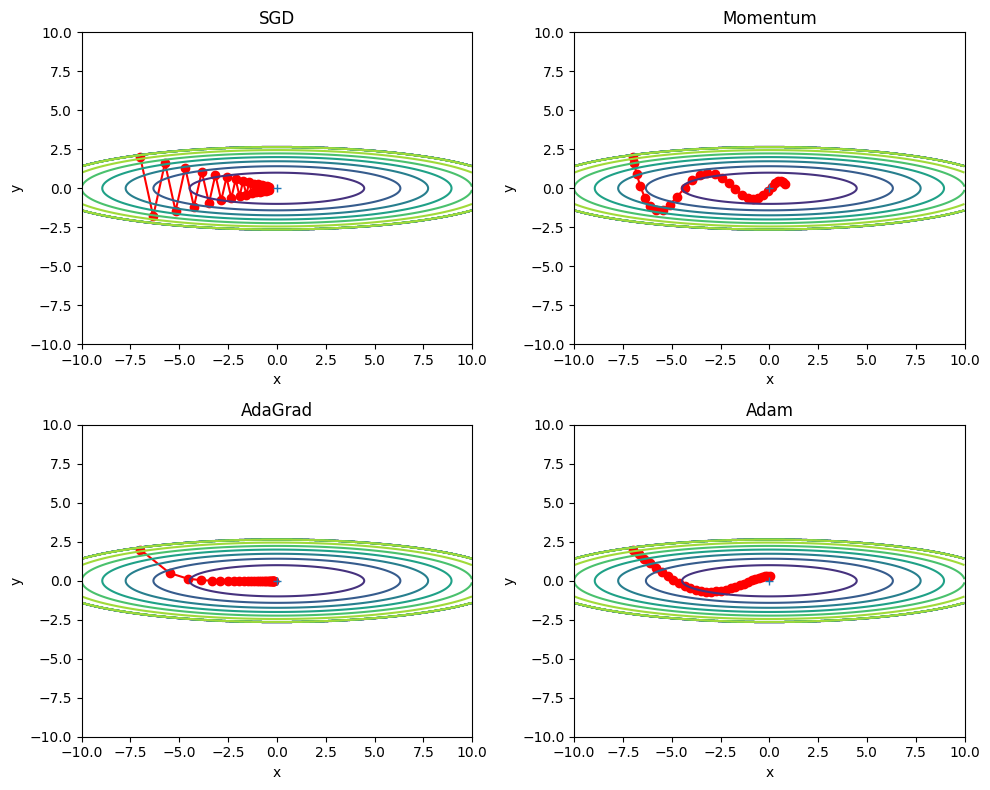

In [ ]:
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1
plt.figure(figsize=(10, 8))

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # for simple contour line  
    mask = Z > 7
    Z[mask] = 0
    
    # plot 
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.tight_layout()
plt.show()

Cell 1 の関数 f / df、init_pos、optimizers をそのまま利用して，3D で最適化経路をインタラクティブ可視化（上側をトリミング + アニメーション）を行う．

In [35]:
# Cell 1 の関数 f / df、init_pos、optimizers をそのまま利用して
# 3D で最適化経路をインタラクティブ可視化（上側をトリミング + アニメーション）
import numpy as np

try:
    import plotly.graph_objects as go
except ImportError:
    raise ImportError("plotly が必要です。`pip install plotly` を実行してください。")

params_3d = {'x': init_pos[0], 'y': init_pos[1]}
grads_3d = {'x': 0.0, 'y': 0.0}

trajectory = {}
for key in optimizers:
    optimizer = optimizers[key]
    params_3d['x'], params_3d['y'] = init_pos

    xs, ys, zs = [], [], []
    for _ in range(30):
        x, y = params_3d['x'], params_3d['y']
        xs.append(x)
        ys.append(y)
        zs.append(f(x, y))

        grads_3d['x'], grads_3d['y'] = df(x, y)
        optimizer.update(params_3d, grads_3d)

    trajectory[key] = (np.array(xs), np.array(ys), np.array(zs))

x = np.linspace(-10, 10, 120)
y = np.linspace(-5, 5, 120)
X, Y = np.meshgrid(x, y)
Z_raw = f(X, Y)

# 関数上部をトリミングして見やすくする
z_cap = 12.0
Z = np.clip(Z_raw, 0, z_cap)

fig = go.Figure()
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale='Viridis',
    opacity=0.72,
    showscale=False,
    name='f(x, y)'
))

colors = {
    'SGD': '#EF553B',
    'Momentum': '#00CC96',
    'AdaGrad': '#636EFA',
    'Adam': '#FFA15A'
}

keys = list(trajectory.keys())
for key in keys:
    xs, ys, zs = trajectory[key]
    fig.add_trace(go.Scatter3d(
        x=xs[:1], y=ys[:1], z=np.clip(zs[:1], 0, z_cap),
        mode='lines+markers',
        name=key,
        line=dict(width=6, color=colors.get(key, '#FFFFFF')),
        marker=dict(size=3, color=colors.get(key, '#FFFFFF'))
    ))

n_steps = max(len(v[0]) for v in trajectory.values())
frames = []
for t in range(n_steps):
    frame_data = []
    for key in keys:
        xs, ys, zs = trajectory[key]
        frame_data.append(go.Scatter3d(
            x=xs[:t+1],
            y=ys[:t+1],
            z=np.clip(zs[:t+1], 0, z_cap),
            mode='lines+markers',
            line=dict(width=6, color=colors.get(key, '#FFFFFF')),
            marker=dict(size=3, color=colors.get(key, '#FFFFFF'))
        ))
    frames.append(go.Frame(data=frame_data, traces=list(range(1, 1 + len(keys))), name=str(t)))

fig.frames = frames

fig.update_layout(
    title='Optimizer Trajectories on f(x, y) = x^2/20 + y^2',
    width=1000,
    height=700,
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        zaxis=dict(range=[0, z_cap]),
        camera=dict(eye=dict(x=1.5, y=1.25, z=0.8))
    ),
    legend=dict(x=0.02, y=0.98),
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'x': 0.02,
        'y': 1.08,
        'buttons': [
            {
                'label': 'Play',
                'method': 'animate',
                'args': [None, {'frame': {'duration': 140, 'redraw': True}, 'fromcurrent': True}]
            },
            {
                'label': 'Pause',
                'method': 'animate',
                'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]
            }
        ]
    }],
    sliders=[{
        'active': 0,
        'x': 0.18,
        'y': 1.06,
        'len': 0.75,
        'steps': [
            {
                'label': str(t),
                'method': 'animate',
                'args': [[str(t)], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}}]
            }
            for t in range(n_steps)
        ]
    }]
)

fig.show()


# ch06/optimizer_compare_mnist.py

MNISTを使って **SGD / Momentum / AdaGrad / Adam** の4つの最適化手法を比較し，**損失（loss）の下がり方**をグラフで確認する．

### 処理内容

* MNISTを読み込む
* 5層の各層100個のニューロンを持つネットワークを対象にする
* ミニバッチ学習を2000回実行
* 各手法のlossを記録
* lossの推移をプロットして比較

### このコードで分かること

* この例では，SGD より Momentum / AdaGrad / Adam の方が早く損失が下がりやすい傾向が見られる．


===========iteration:0===========
SGD:2.3552897324047866
Momentum:2.361099438306561
AdaGrad:2.404846932983569
Adam:2.2828951272429863
===========iteration:100===========
SGD:1.5708821931232821
Momentum:0.3046052565263182
AdaGrad:0.1127252288187777
Adam:0.23820927332577974
===========iteration:200===========
SGD:0.752170369787196
Momentum:0.2538277144973096
AdaGrad:0.09713951798898124
Adam:0.16718268982363826
===========iteration:300===========
SGD:0.4367250809477158
Momentum:0.1918328198257877
AdaGrad:0.08696837097912721
Adam:0.0843038621209662
===========iteration:400===========
SGD:0.537314468307891
Momentum:0.21419958640227185
AdaGrad:0.12247505142912372
Adam:0.24918190356536407
===========iteration:500===========
SGD:0.3496018034924627
Momentum:0.20029327833975427
AdaGrad:0.06498092508229888
Adam:0.1575114589536478
===========iteration:600===========
SGD:0.38783528986861626
Momentum:0.1260498668609716
AdaGrad:0.04816691486380169
Adam:0.05235616629985174
===========iteration:700====

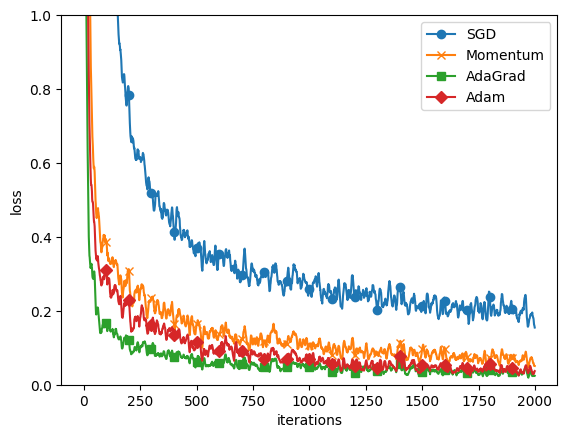

In [ ]:
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()


# ch06/weight_init_activation_histogram.py

**多層ニューラルネットワークで各層の活性化値がどのような分布になるか**を確認する．

### 処理内容

* ランダムな入力データを作成
* 5層の隠れ層に順番に入力を通す
* 各層で

  * 線形変換 `a = xW`
  * 活性化関数 `z = sigmoid(a)`（※ここは切替可能）
* 各層の出力 `z` の分布をヒストグラムで表示

### このコードの設定（現在）

* 活性化関数：`sigmoid`
* 重み初期値：`標準偏差1`（`* 1`）

この設定だと、値が端に寄りやすく，勾配消失の原因になりやすい．

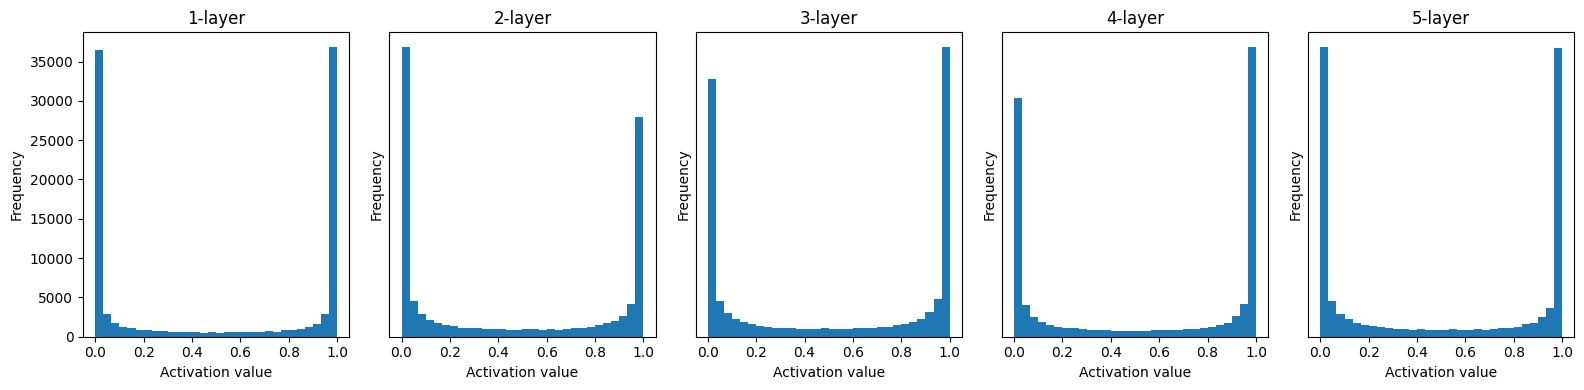

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)
    
input_data = np.random.randn(1000, 100)  # 1000個のデータ
node_num = 100  # 各隠れ層のノード（ニューロン）の数
hidden_layer_size = 5  # 隠れ層が5層
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 初期値の値をいろいろ変えて実験しよう！
    w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    # w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    # w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)


    # 活性化関数の種類も変えて実験しよう！
    z = sigmoid(a)
    # z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# ヒストグラムを描画
plt.figure(figsize=(16, 4))
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.xlabel("Activation value")   # 横軸
    plt.ylabel("Frequency")          # 縦軸
    if i != 0: plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0,1))
plt.tight_layout()
plt.show()


# ch06/weight_init_compare.py

重みの初期値の与え方（初期化方法）によって学習の進み方がどう変わるかを，MNISTで比較する．

### 処理内容

* 同じネットワーク構造を3つ用意
* 初期化方法だけを変える

  * `std=0.01`（小さい固定値）
  * `Xavier`（sigmoid向け）
  * `He`（ReLU向け）
* 同じ最適化手法（`SGD`）で学習
* 各モデルのlossを記録して比較

### この図で分かること

* **初期化方法によって学習速度・収束性が変わる**
* `std=0.01` はほとんど学習が進まない
* `Xavier` と `He` は学習が進みやすく，特に `He` は速く loss が下がりやすい

### このコードで分かること

* 学習において，**重み初期化は重要**
* 活性化関数に合った初期化を使うと学習が安定しやすい

===========iteration:0===========
std=0.01:2.3025211990303274
Xavier:2.3094134480277964
He:2.425856669196355
===========iteration:100===========
std=0.01:2.3019040534022706
Xavier:2.260584880323231
He:1.2722569577868268
===========iteration:200===========
std=0.01:2.302748087308742
Xavier:2.214095728886312
He:0.7841491129918229
===========iteration:300===========
std=0.01:2.2998112828577852
Xavier:2.044342813304527
He:0.4820002757413533
===========iteration:400===========
std=0.01:2.3018759041439223
Xavier:1.6666156644126566
He:0.4456562132511389
===========iteration:500===========
std=0.01:2.2992736886423337
Xavier:1.0407903064762976
He:0.29959406992630483
===========iteration:600===========
std=0.01:2.295206817258441
Xavier:0.7491439861931606
He:0.33083770802198836
===========iteration:700===========
std=0.01:2.3013652499123487
Xavier:0.7327198639413826
He:0.4618992100419918
===========iteration:800===========
std=0.01:2.30118873877739
Xavier:0.5295285288521112
He:0.21675167126010186

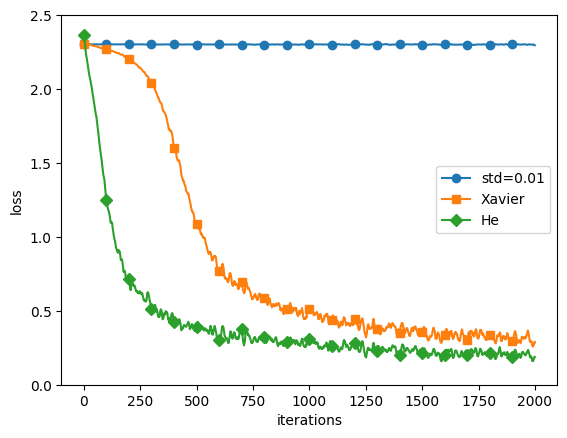

In [ ]:
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

ch06_02.ipynbに続く